In [5]:
# Re-import libraries after code execution state reset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
# Environment setup
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size) # the rewards have been presented as matrix as well
# Higher rewards for terminal states
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0

actions = ['U', 'D', 'L', 'R']
action_to_delta = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}
gamma = 0.9 # discount factpr
theta = 1e-4 # threshold for  iterative method convergence

In [9]:
# Stochastic transition model (80% intended direction, 10% left, 10% right)
# Non-deterministic implementation
def get_transitions(state, action):
    if state in terminal_states:
        return [(1.0, state)]
    
    directions = ['U', 'R', 'D', 'L']
    idx = directions.index(action)
    probabilities = [0.8, 0.1, 0.0, 0.1]  # intended, right, opposite, left

    transitions = []
    for i, p in enumerate(probabilities):
        # rotate clockwise through the action space
        real_action = directions[(idx + i) % 4]
        delta = action_to_delta[real_action]
        next_state = (state[0] + delta[0], state[1] + delta[1])
        if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
            transitions.append((p, next_state))
        else:
            transitions.append((p, state))  # hit wall, stay in place
    return transitions 

# Value Iteration
def value_iteration():
    V = np.zeros(grid_size)
    iteration_snapshots = []
    while True:
        delta = 0
        new_V = np.copy(V)
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                state = (i, j)
                if state in terminal_states:
                    continue
                action_values = []
                for action in actions:
                    value = 0
                    for p, s_prime in get_transitions(state, action): # get transition probability and next state
                        value += p * (rewards[s_prime] + gamma * V[s_prime]) # reward gets multiplied by transition probability if the reward depends on state
                    action_values.append(value)
                best_value = max(action_values)
                delta = max(delta, np.abs(best_value - V[state]))
                new_V[state] = best_value
        V = new_V
        iteration_snapshots.append(V.copy())
        if delta < theta:
            break

    # Extract policy
    policy = np.full(grid_size, '', dtype=object)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            state = (i, j)
            if state in terminal_states:
                policy[state] = 'T'
                continue
            values = []
            for action in actions:
                value = 0
                for p, s_prime in get_transitions(state, action):
                    value += p * (rewards[s_prime] + gamma * V[s_prime])
                values.append((value, action))
            policy[state] = max(values, key=lambda x: x[0])[1]
    return V, policy, iteration_snapshots

# Policy Iteration
def policy_iteration():
    policy = np.random.choice(actions, size=grid_size)
    V = np.zeros(grid_size)
    iteration_snapshots = []

    is_policy_stable = False
    while not is_policy_stable:
        # Policy Evaluation
        while True:
            delta = 0
            new_V = np.copy(V)
            for i in range(grid_size[0]):
                for j in range(grid_size[1]):
                    state = (i, j)
                    if state in terminal_states:
                        continue
                    action = policy[state]
                    value = 0
                    for p, s_prime in get_transitions(state, action):
                        value += p * (rewards[s_prime] + gamma * V[s_prime])
                    delta = max(delta, np.abs(value - V[state]))
                    new_V[state] = value
            V = new_V
            if delta < theta:
                break

        iteration_snapshots.append(V.copy())

        # Policy Improvement
        is_policy_stable = True
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                state = (i, j)
                if state in terminal_states:
                    policy[state] = 'T'
                    continue
                old_action = policy[state]
                values = []
                for action in actions:
                    value = 0
                    for p, s_prime in get_transitions(state, action):
                        value += p * (rewards[s_prime] + gamma * V[s_prime])
                    values.append((value, action))
                best_action = max(values, key=lambda x: x[0])[1]
                policy[state] = best_action
                if old_action != best_action:
                    is_policy_stable = False
    return V, policy, iteration_snapshots

In [10]:
def plot_policy_and_value(V, policy, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            ax.add_patch(patches.Rectangle((j, grid_size[0]-1-i), 1, 1, fill=False))
            ax.text(j + 0.5, grid_size[0]-1-i + 0.6, f"{V[i, j]:.2f}", ha='center', fontsize=8)
            ax.text(j + 0.5, grid_size[0]-1-i + 0.25, policy[i, j], ha='center', fontsize=12, fontweight='bold')
    ax.set_xlim(0, grid_size[1])
    ax.set_ylim(0, grid_size[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot snapshots for value function convergence
def plot_snapshots(snapshots, title_prefix):
    for i, V in enumerate(snapshots[::max(1, len(snapshots)//5)]):
        fig, ax = plt.subplots()
        c = ax.imshow(V, cmap='coolwarm', origin='upper')
        ax.set_title(f"{title_prefix} - Iteration {i+1}")
        fig.colorbar(c)
        plt.show()

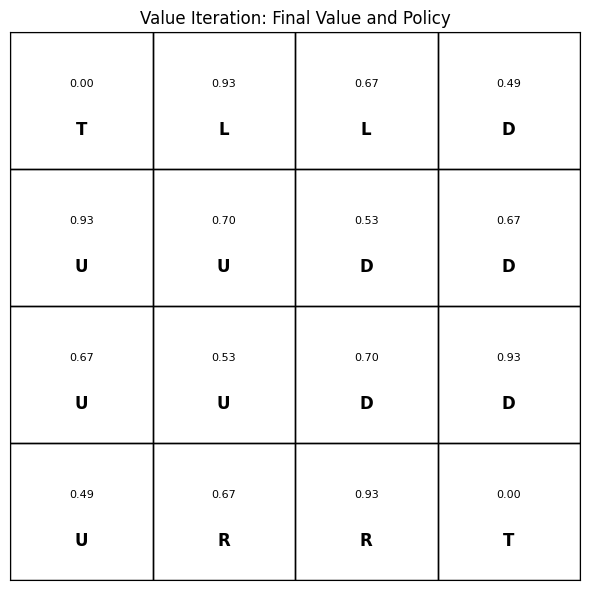

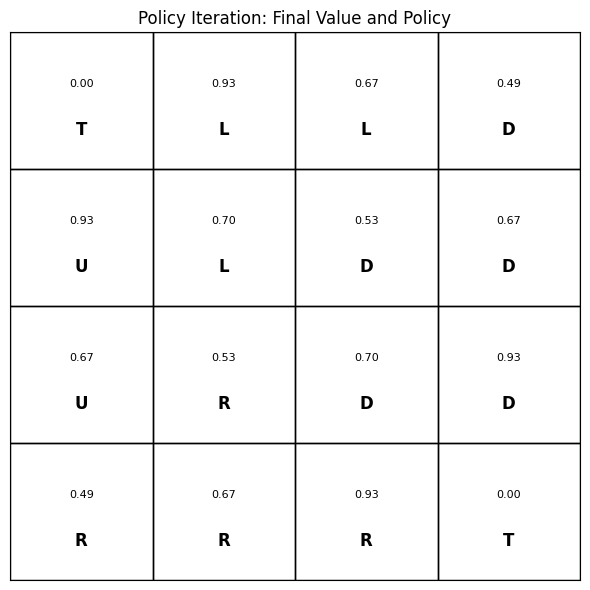

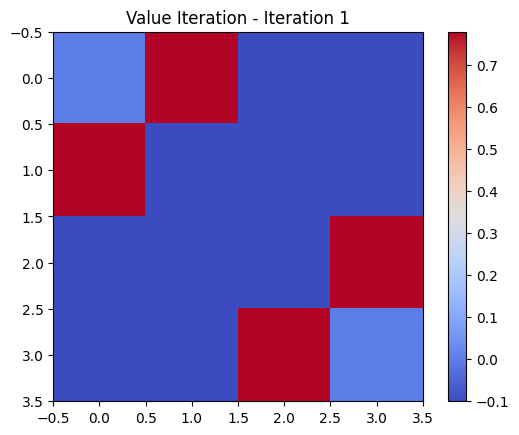

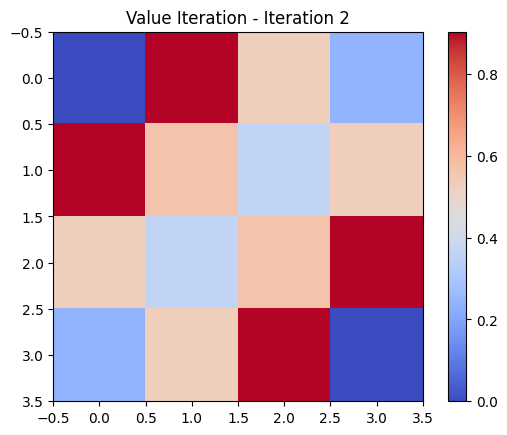

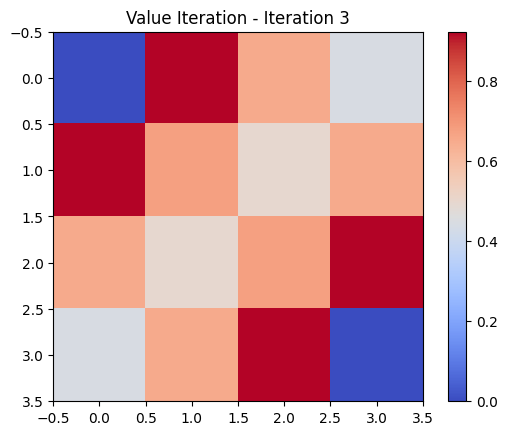

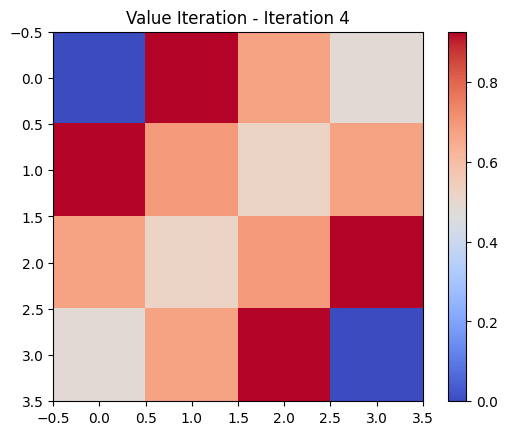

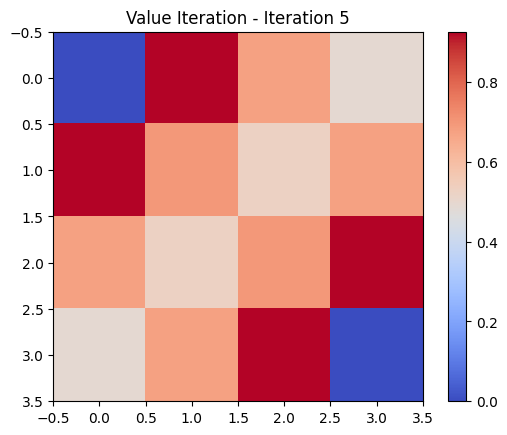

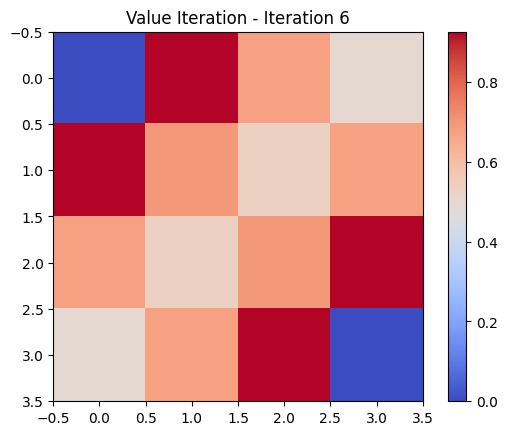

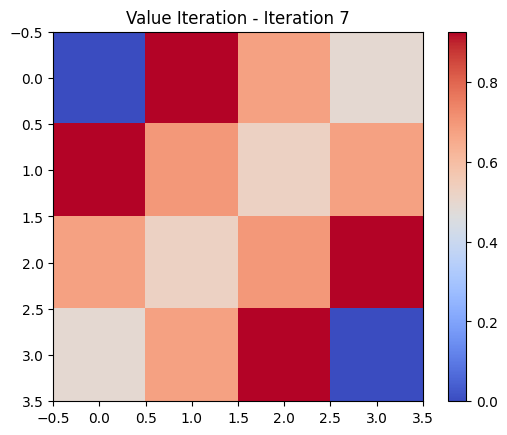

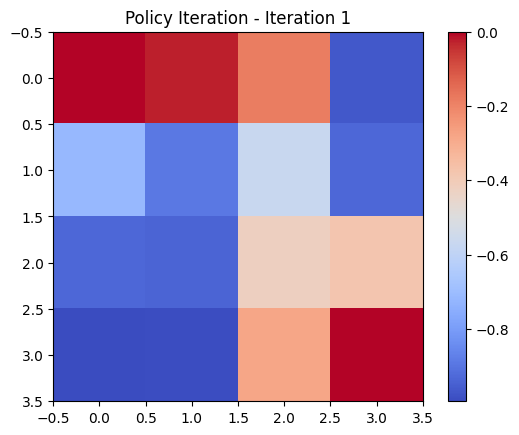

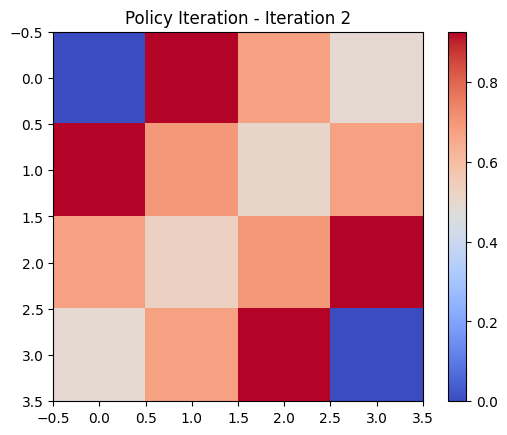

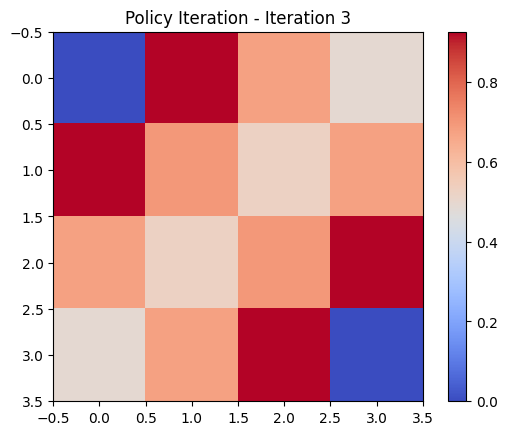

In [11]:
# Run both algorithms
V_vi, policy_vi, snapshots_vi = value_iteration()
V_pi, policy_pi, snapshots_pi = policy_iteration()

# Plot final results
plot_policy_and_value(V_vi, policy_vi, "Value Iteration: Final Value and Policy")
plot_policy_and_value(V_pi, policy_pi, "Policy Iteration: Final Value and Policy")

plot_snapshots(snapshots_vi, "Value Iteration")
plot_snapshots(snapshots_pi, "Policy Iteration")
